In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

In [3]:
# opne csv file
csv_file = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\AI_MODEL\SPL_PREDICTIONS\P1_CONTENEDORES_v1_1.csv"
df = pd.read_csv(csv_file)
df

,filename,timestamp,LA,LC,LZ,LAmax,LAmin,class,probability
0,20231217_002245.WAV,2023-12-17 00:22:45,67.23,72.73,72.88,68.28,66.41,NaN,NaN
1,20231217_002245.WAV,2023-12-17 00:22:46,67.92,73.49,73.69,69.05,66.62,Vehicle,0.4445
2,20231217_002245.WAV,2023-12-17 00:22:47,68.61,74.57,74.87,69.70,67.88,Vehicle,0.6117
3,20231217_002245.WAV,2023-12-17 00:22:48,71.78,77.20,77.56,72.73,70.88,Vehicle,0.5862
4,20231217_002245.WAV,2023-12-17 00:22:49,74.63,80.07,80.37,76.86,72.06,Vehicle,0.3977
...,...,...,...,...,...,...,...,...,...
445,20231217_002245.WAV,2023-12-17 00:30:10,63.98,68.85,68.93,64.74,62.54,NaN,NaN
446,20231217_002245.WAV,2023-12-17 00:30:11,64.22,69.00,69.08,64.76,63.24,Vehicle,0.3293
447,20231217_002245.WAV,2023-12-17 00:30:12,64.23,68.91,69.00,64.96,63.53,NaN,NaN
448,20231217_002245.WAV,2023-12-17 00:30:13,65.51,70.07,70.16,66.47,64.88,NaN,NaN


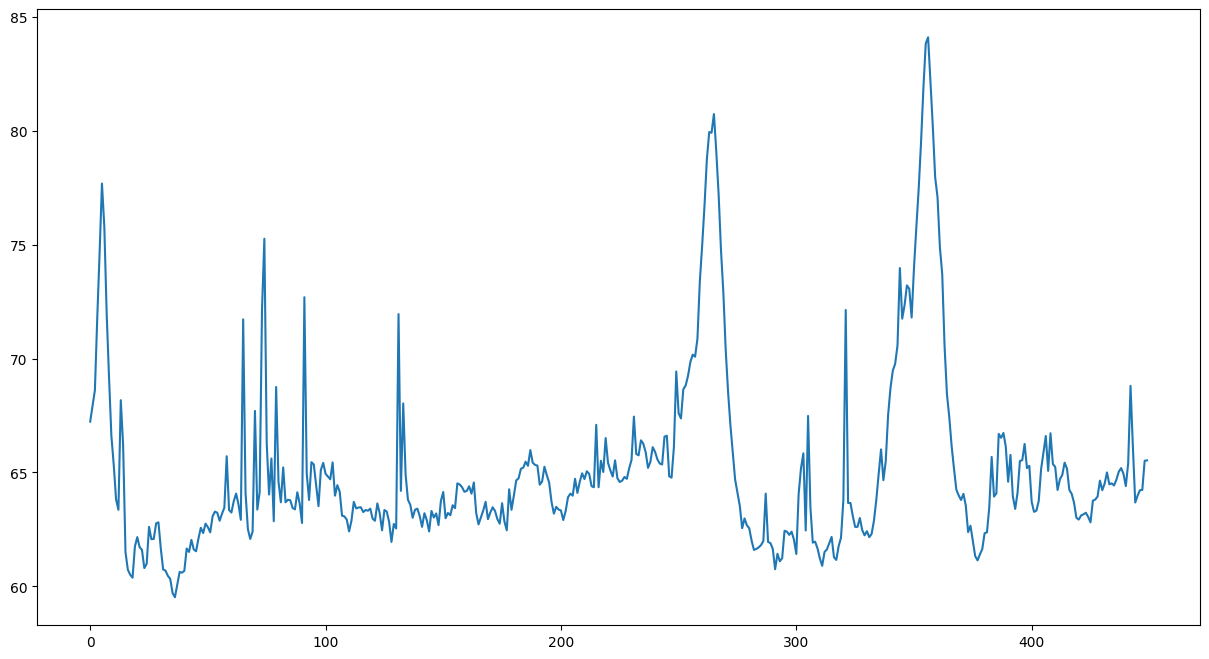

In [7]:
# plot LA column values over time
figure = plt.figure(figsize=(15, 8))
plt.plot(df['LA'])
plt.show()

In [28]:
la = df['LA'].values
print('Max:', np.max(la).round(2))
print('Min:', np.min(la).round(2))
print('Mediana:', np.median(la).round(2))
print('Promedio:', np.mean(la).round(2))
print('Standard deviation:', np.std(la).round(2))
print('Percentil 98:', np.quantile(la, 0.99).round(2))

Max: 84.1
Min: 59.52
Mediana: 64.06
Promedio: 65.14
Standard deviation: 4.07
Percentil 98: 80.46


# Peak detection for Port Environment

Mediana: 64.06
Promedio: 65.14
Standard deviation: 4.07
Percentil 98: 80.46


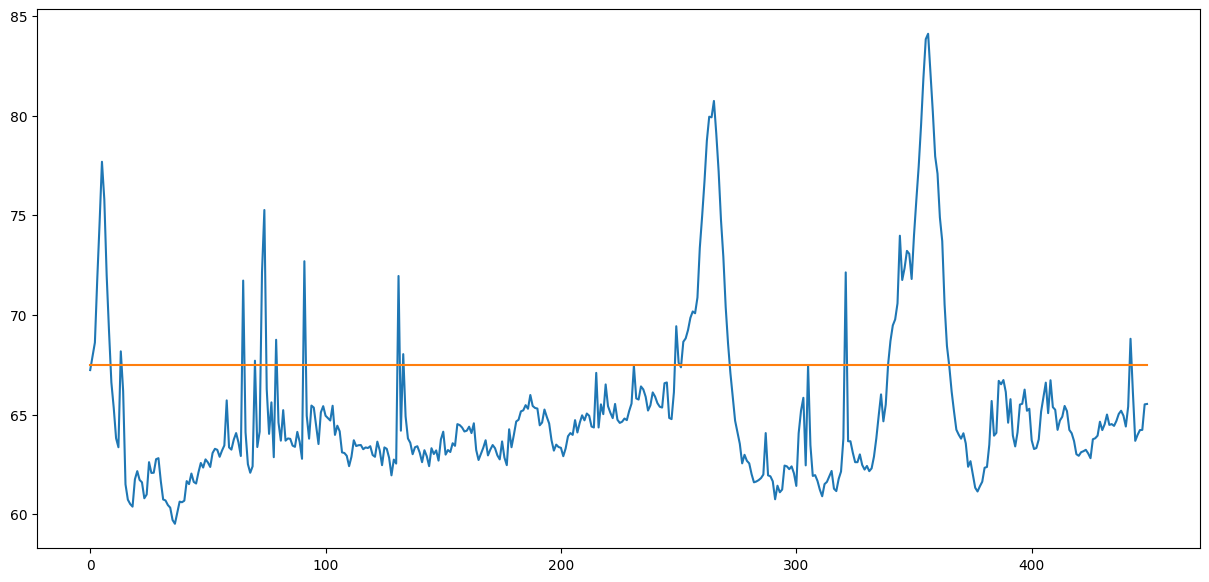

In [25]:
la = df.LA.values
l99 = np.quantile(la, 0.85)
umbral = l99 * np.ones([1, len(la)])

plt.figure(figsize=(15,7))
plt.plot(la)
plt.plot(umbral[0])

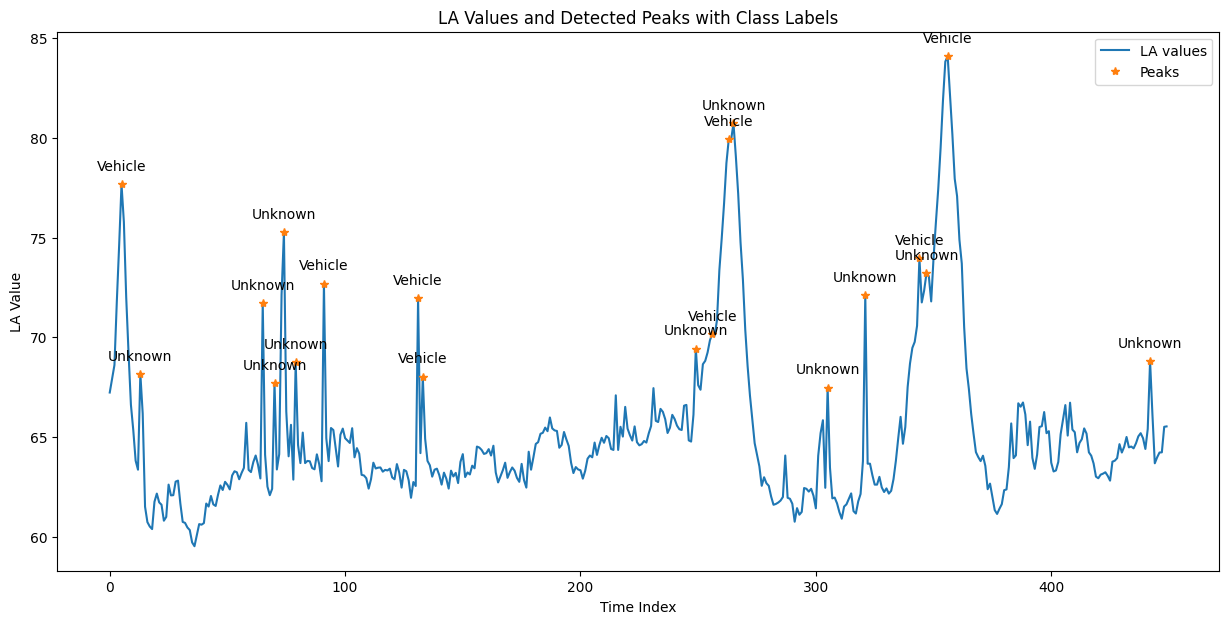

In [21]:
la = df['LA'].values
threshold = np.quantile(la, 0.85)

#peaks above the threshold
peak_idx, peak_dict = signal.find_peaks(la, height=threshold)
peak_values = la[peak_idx]

# la values and the detected peaks
plt.figure(figsize=(15, 7))
plt.plot(la, label='LA values')
plt.plot(peak_idx, peak_values, '*', label='Peaks')

#peaks with class labels or "Unknown"
for i, idx in enumerate(peak_idx):
    label = df['class'][idx]
    if pd.isna(label):  
        label = "Unknown"
    plt.annotate(label, (idx, la[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('LA Values and Detected Peaks with Class Labels')
plt.xlabel('Time Index')
plt.ylabel('LA Value')
plt.legend()
plt.show()